In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_parquet("../data/processed/loans_clean.parquet")
print(f"Loaded {len(df):,} rows")
print(f"Delinquency rate: {df['delq90'].mean():.2%}")

Loaded 2,258,957 rows
Delinquency rate: 12.87%


In [2]:
# Features for the model
# months_obs removed — it uses post-origination data (last payment date)
# and would constitute leakage in an application-time scoring model.
# It remains appropriate for survival analysis and LGD timing work.
features = [
    "int_rate", "dti", "fico", "loan_amnt",
    "annual_inc", "revol_util", "delinq_2yrs",
    "open_acc", "pub_rec", "term"
]

grade_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
df["grade_num"] = df["grade"].map(grade_map)
features.append("grade_num")

In [3]:
# Features and train/test split
model_df = df[features + ["delq90"]].dropna()
print(f"Model dataset: {len(model_df):,} rows")

X = model_df[features]
y = model_df["delq90"]

df_idx = df.loc[model_df.index, "issue_year"]
train_mask = df_idx <= 2017
test_mask  = df_idx == 2018

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {len(X_train):,} loans ({y_train.mean():.2%} delinquency)")
print(f"Test:  {len(X_test):,} loans  ({y_test.mean():.2%} delinquency)")

Model dataset: 2,257,159 rows
Train: 1,763,639 loans (15.56% delinquency)
Test:  493,520 loans  (3.25% delinquency)


In [4]:
# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Fit logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# Predictions
y_pred_proba = lr.predict_proba(X_test_sc)[:, 1]
y_pred       = lr.predict(X_test_sc)

# AUC on test set
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")

# Coefficient table
coef_df = pd.DataFrame({
    "feature":     features,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nCoefficients (scaled — larger = stronger predictor):")
print(coef_df.to_string(index=False))

Test AUC: 0.6804

Coefficients (scaled — larger = stronger predictor):
    feature  coefficient
  grade_num     0.454675
  loan_amnt     0.079637
   open_acc     0.057126
       term     0.052812
   int_rate     0.051402
        dti     0.038126
    pub_rec     0.014656
delinq_2yrs    -0.007802
 revol_util    -0.050666
       fico    -0.208702
 annual_inc    -0.368535


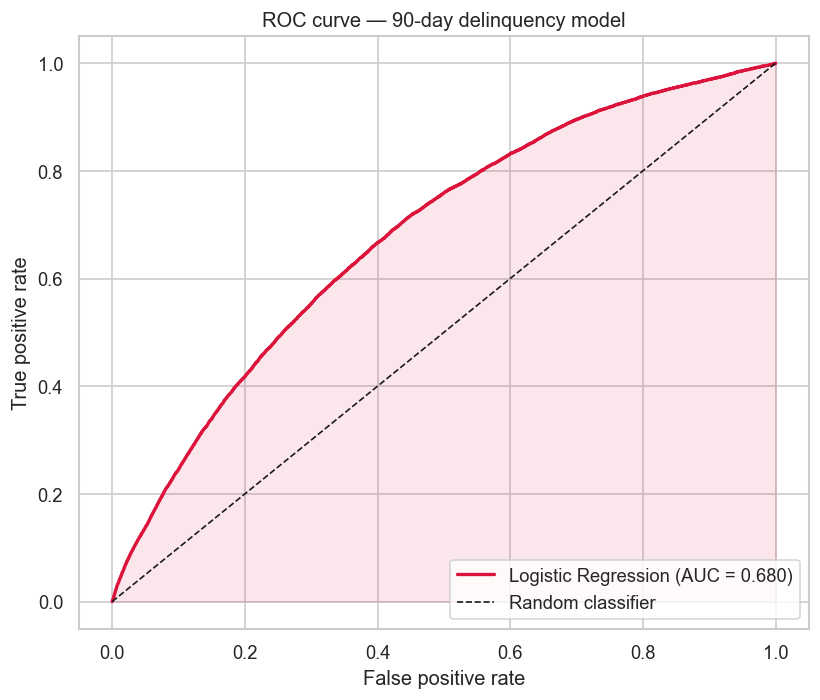

In [5]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="crimson", linewidth=2,
        label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.1, color="crimson")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — 90-day delinquency model")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../output/figures/roc_curve.png", dpi=150)
plt.show()

Survival dataset: 100,000 rows


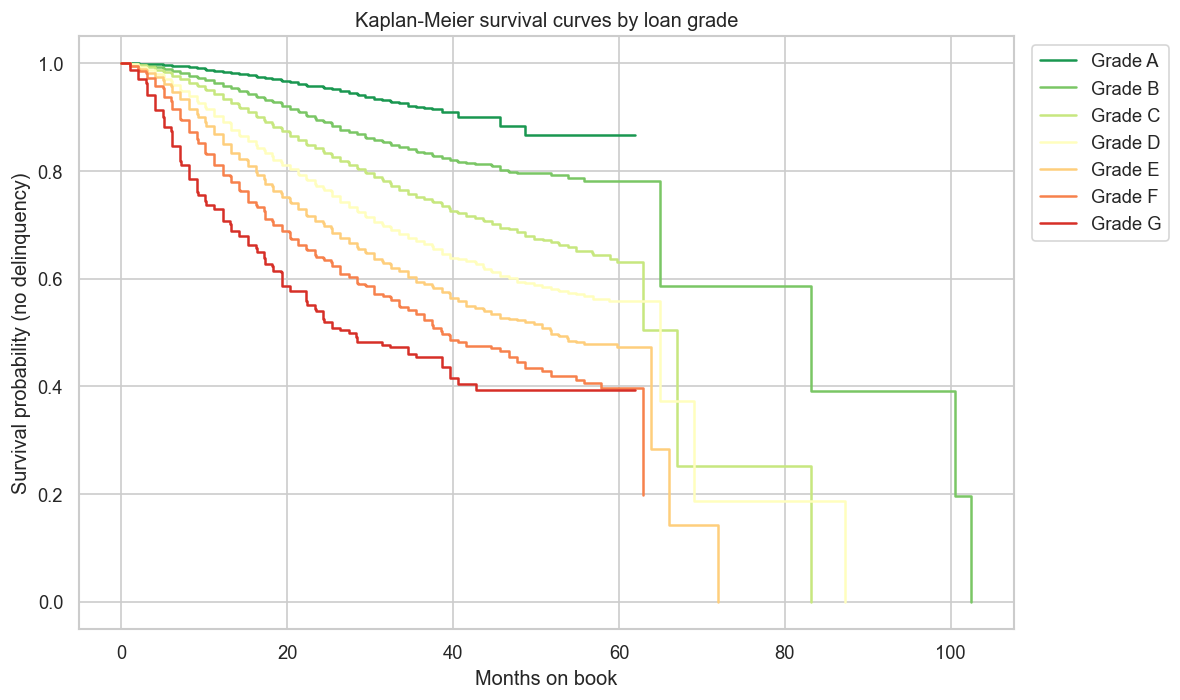

In [6]:
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter

# Prepare survival dataset
# duration = months_obs, event = delq90
surv_features = ["months_obs", "delq90", "int_rate", 
                 "dti", "fico", "annual_inc", "grade_num", "term"]

surv_df = df[surv_features].dropna()

# Sample for speed (Cox is slow on 2M rows)
surv_sample = surv_df.sample(100_000, random_state=42)
print(f"Survival dataset: {len(surv_sample):,} rows")

# Kaplan-Meier curves by grade
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 7))

for grade_num, grade_letter, color in zip(
        range(1, 8), ["A","B","C","D","E","F","G"], colors):
    mask = surv_sample["grade_num"] == grade_num
    kmf = KaplanMeierFitter()
    kmf.fit(surv_sample.loc[mask, "months_obs"],
            event_observed=surv_sample.loc[mask, "delq90"],
            label=f"Grade {grade_letter}")
    kmf.plot_survival_function(ax=ax, color=color, ci_show=False)

ax.set_xlabel("Months on book")
ax.set_ylabel("Survival probability (no delinquency)")
ax.set_title("Kaplan-Meier survival curves by loan grade")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../output/figures/kaplan_meier_by_grade.png",
            dpi=150, bbox_inches="tight")
plt.show()

<lifelines.CoxPHFitter: fitted with 100000 total observations, 87024 right-censored observations>
             duration col = 'months_obs'
                event col = 'delq90'
      baseline estimation = breslow
   number of observations = 100000
number of events observed = 12976
   partial log-likelihood = -137935.105
         time fit was run = 2026-05-31 00:30:53 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
int_rate    7.645  2091.098     0.531           6.604           8.687             737.987            5925.160
dti         0.001     1.001     0.000           0.000           0.002               1.000               1.002
fico       -0.003     0.997     0.000          -0.003          -0.002               0.997               0.998
annual_inc -0.000     1.000     0.000          -0.000          -0.000               1.000               1.000
grade_num   0.127     1.136     0.020           0.088           0.167               1.091               1.181
term       -0.005     0.995     0.001          -0.007          -0.003               0.993               0.997

            cmp to      z       p  -log2(p)
covariate                                  
int_rate     0.000 14.387 <0.0005   153.497
dti          0.000  2.667   0.008     7.030
fico         0.000 -7.679 <0.0005    45.826
annual_inc   0.000 -4.321 <0.0005    15.972
grade_num    0.000  6.292 <0.0005    31.568
term         0.000 -5.981 <0.0005    28.747
---
Concordance = 0.673
Partial AIC = 275882.210
log-likelihood ratio test = 4245.650 on 6 df
-log2(p) of ll-ratio test = inf

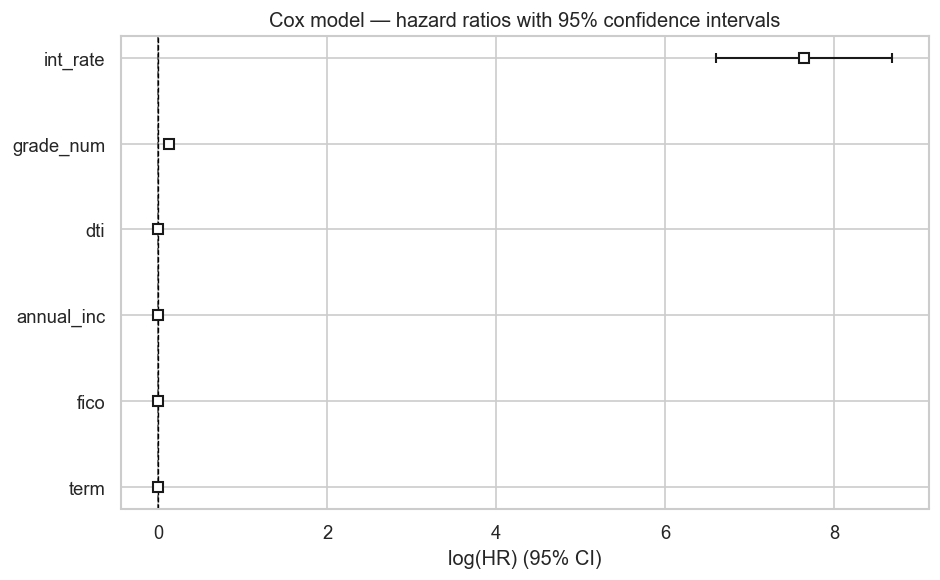

In [7]:
# Cox proportional hazards model
cph = CoxPHFitter()
cph.fit(surv_sample, 
        duration_col="months_obs",
        event_col="delq90")

cph.print_summary(decimals=3)

# Plot hazard ratios
fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax)
ax.set_title("Cox model — hazard ratios with 95% confidence intervals")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("../output/figures/cox_hazard_ratios.png",
            dpi=150, bbox_inches="tight")
plt.show()

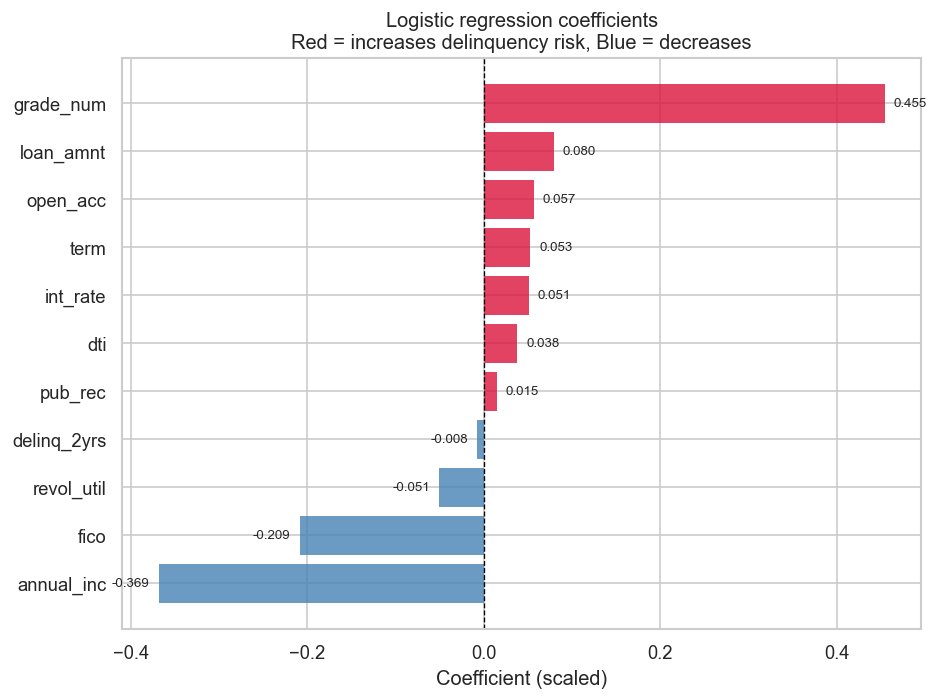

In [8]:
# Coefficient bar chart
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient")

colors = ["crimson" if c > 0 else "steelblue" for c in coef_df["coefficient"]]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(coef_df["feature"], coef_df["coefficient"],
               color=colors, alpha=0.8, edgecolor="none")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coefficient (scaled)")
ax.set_title("Logistic regression coefficients\nRed = increases delinquency risk, Blue = decreases")

# Add value labels
for bar, val in zip(bars, coef_df["coefficient"]):
    ax.text(val + (0.01 if val > 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center",
            ha="left" if val > 0 else "right", fontsize=8)

plt.tight_layout()
plt.savefig("../output/figures/logistic_coefficients.png", dpi=150)
plt.show()

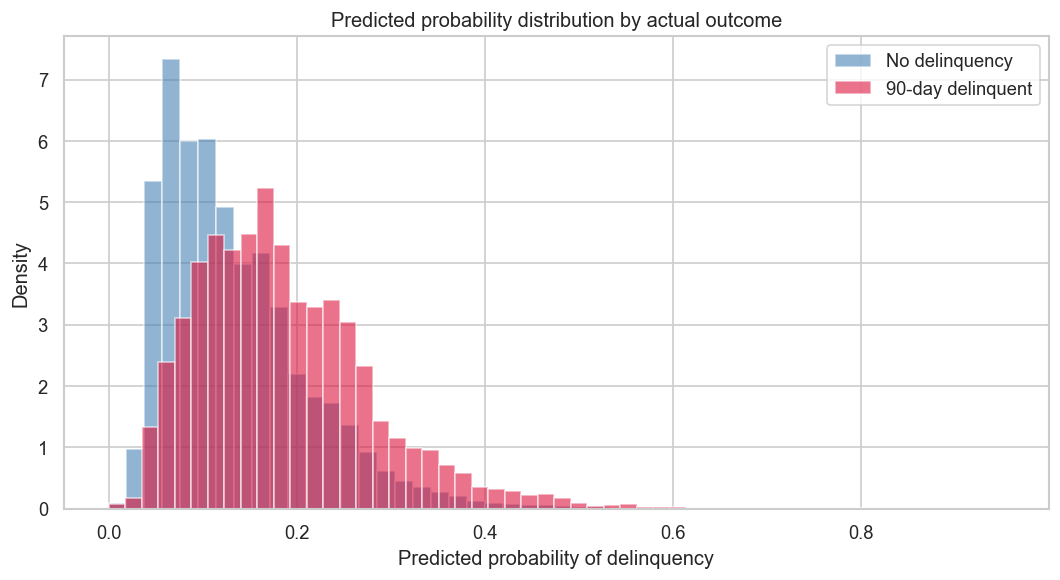

In [9]:
# Predicted probability distribution
y_pred_proba_train = lr.predict_proba(X_train_sc)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.6,
        color="steelblue", label="No delinquency", density=True)
ax.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.6,
        color="crimson", label="90-day delinquent", density=True)

ax.set_xlabel("Predicted probability of delinquency")
ax.set_ylabel("Density")
ax.set_title("Predicted probability distribution by actual outcome")
ax.legend()

plt.tight_layout()
plt.savefig("../output/figures/predicted_probability_dist.png", dpi=150)
plt.show()


In [10]:
# ── Stage 2: Loss Given Default (LGD) ────────────────────────────────────────
# Only look at loans that actually went delinquent
lgd_df = df[df["delq90"] == 1].copy()

# Calculate loss amount and LGD ratio
lgd_df["loss_amt"] = (lgd_df["loan_amnt"] - lgd_df["total_pymnt"]).clip(lower=0)
lgd_df["lgd"] = (lgd_df["loss_amt"] / lgd_df["loan_amnt"]).clip(0, 1)

print(f"Defaulted loans: {len(lgd_df):,}")
print(f"\nLGD summary:")
print(lgd_df["lgd"].describe().round(3))
print(f"\nMean loss per defaulted loan: ${lgd_df['loss_amt'].mean():,.0f}")
print(f"Total loss across portfolio:  ${lgd_df['loss_amt'].sum():,.0f}")

Defaulted loans: 290,732

LGD summary:
count    290732.000
mean          0.468
std           0.266
min           0.000
25%           0.262
50%           0.495
75%           0.680
max           1.000
Name: lgd, dtype: float64

Mean loss per defaulted loan: $7,467
Total loss across portfolio:  $2,170,775,715


In [11]:
import statsmodels.api as sm

# Features for LGD model
lgd_features = ["int_rate", "dti", "fico", "loan_amnt",
                "annual_inc", "revol_util", "grade_num", "term", "months_obs"]

lgd_clean = lgd_df[lgd_features + ["lgd"]].dropna()

X_lgd = lgd_clean[lgd_features]
y_lgd = lgd_clean["lgd"]

# Add constant for intercept
X_lgd_sm = sm.add_constant(X_lgd)

# Fit OLS
ols_model = sm.OLS(y_lgd, X_lgd_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    lgd   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                 9.091e+04
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        20:30:54   Log-Likelihood:             1.6734e+05
No. Observations:              290519   AIC:                        -3.347e+05
Df Residuals:                  290509   BIC:                        -3.346e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4473      0.008     55.244      0.0

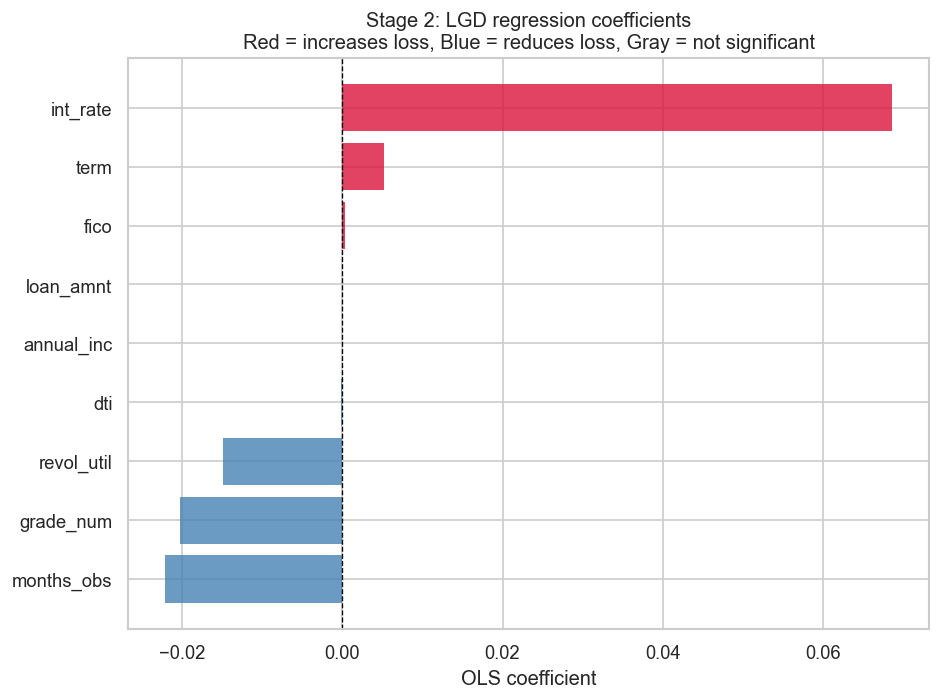


EXPECTED LOSS BY GRADE (PD × LGD × Exposure)
Grade A:  PD=3.59%  LGD=45.72%  EL=$103.7M
Grade B:  PD=8.66%  LGD=45.38%  EL=$369.3M
Grade C:  PD=14.37%  LGD=47.01%  EL=$659.6M
Grade D:  PD=20.36%  LGD=47.43%  EL=$491.7M
Grade E:  PD=28.30%  LGD=46.78%  EL=$313.1M
Grade F:  PD=36.44%  LGD=47.39%  EL=$137.9M
Grade G:  PD=40.03%  LGD=50.64%  EL=$50.2M

Total Expected Loss: $2125.6M


In [12]:
# Plot OLS coefficients
coef_table = pd.DataFrame({
    "feature":     lgd_features,
    "coef":        ols_model.params[1:].values,
    "pvalue":      ols_model.pvalues[1:].values,
})
coef_table["significant"] = coef_table["pvalue"] < 0.05
coef_table = coef_table.sort_values("coef")

colors = ["crimson" if (s and c > 0) else
          "steelblue" if (s and c < 0) else
          "lightgray"
          for s, c in zip(coef_table["significant"], coef_table["coef"])]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coef_table["feature"], coef_table["coef"],
        color=colors, alpha=0.8, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("OLS coefficient")
ax.set_title("Stage 2: LGD regression coefficients\n"
             "Red = increases loss, Blue = reduces loss, Gray = not significant")
plt.tight_layout()
plt.savefig("../output/figures/lgd_coefficients.png", dpi=150)
plt.show()

# ── Expected Loss = PD × LGD × Exposure ─────────────────────────────────────
print("\n" + "="*55)
print("EXPECTED LOSS BY GRADE (PD × LGD × Exposure)")
print("="*55)

grade_pd  = df.groupby("grade")["delq90"].mean()
grade_lgd = lgd_df.groupby("grade")["lgd"].mean()
grade_exp = df.groupby("grade")["loan_amnt"].sum()

el = pd.DataFrame({
    "PD":       grade_pd,
    "LGD":      grade_lgd,
    "Exposure": grade_exp,
}).assign(EL=lambda x: x["PD"] * x["LGD"] * x["Exposure"])

for grade, row in el.iterrows():
    print(f"Grade {grade}:  PD={row['PD']:.2%}  "
          f"LGD={row['LGD']:.2%}  "
          f"EL=${row['EL']/1e6:.1f}M")

print(f"\nTotal Expected Loss: ${el['EL'].sum()/1e6:.1f}M")

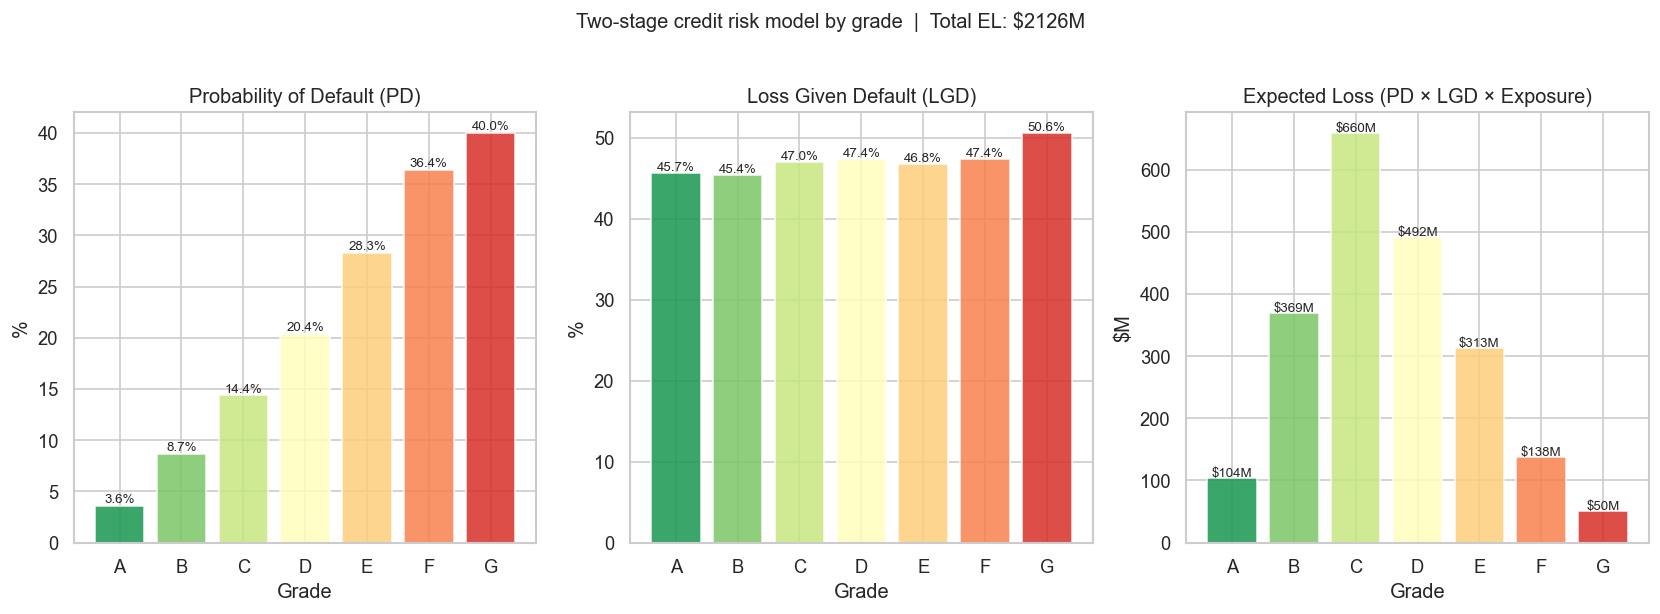

In [13]:
# Expected Loss bar chart by grade
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

grades = el.index.tolist()
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grades)))

# PD by grade
axes[0].bar(grades, el["PD"] * 100, color=colors, alpha=0.85)
axes[0].set_title("Probability of Default (PD)")
axes[0].set_ylabel("%")
for i, v in enumerate(el["PD"] * 100):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)

# LGD by grade
axes[1].bar(grades, el["LGD"] * 100, color=colors, alpha=0.85)
axes[1].set_title("Loss Given Default (LGD)")
axes[1].set_ylabel("%")
for i, v in enumerate(el["LGD"] * 100):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)

# Expected Loss by grade
axes[2].bar(grades, el["EL"] / 1e6, color=colors, alpha=0.85)
axes[2].set_title("Expected Loss (PD × LGD × Exposure)")
axes[2].set_ylabel("$M")
for i, v in enumerate(el["EL"] / 1e6):
    axes[2].text(i, v + 2, f"${v:.0f}M", ha="center", fontsize=8)

for ax in axes:
    ax.set_xlabel("Grade")

plt.suptitle(f"Two-stage credit risk model by grade  |  "
             f"Total EL: ${el['EL'].sum()/1e6:.0f}M",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../output/figures/expected_loss_by_grade.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


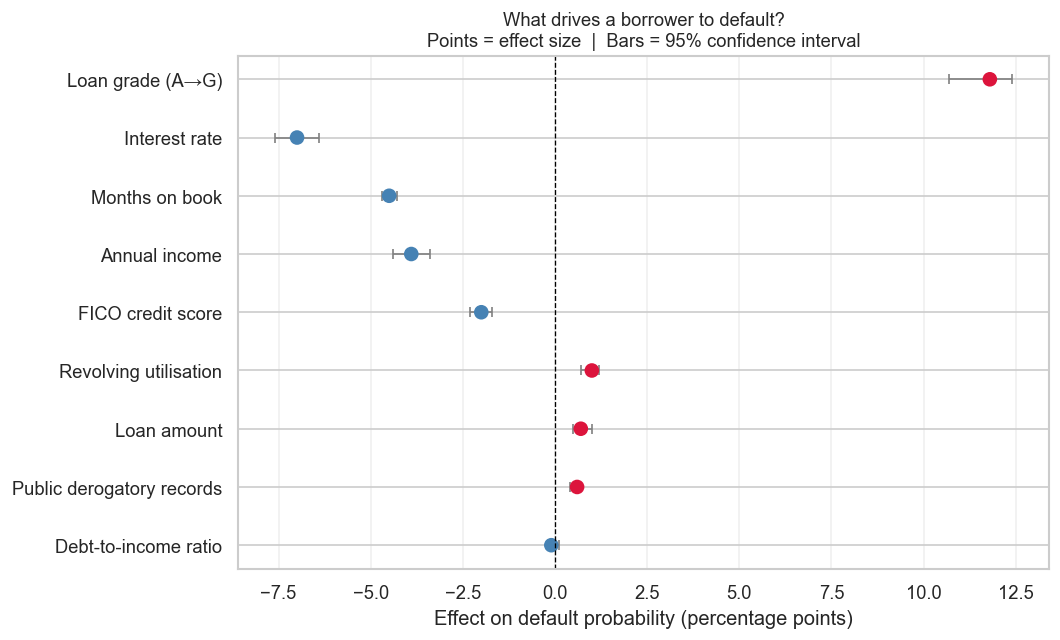

In [15]:
# ── Marginal effects forest plot ─────────────────────────────────────────────
# Effect sizes in percentage points, with 95% confidence intervals
me = pd.DataFrame([
    ("Loan grade (A→G)",          11.8, 10.7, 12.4),
    ("Interest rate",             -7.0, -7.6, -6.4),
    ("Months on book",           -4.5, -4.7, -4.3),
    ("Annual income",            -3.9, -4.4, -3.4),
    ("FICO credit score",        -2.0, -2.3, -1.7),
    ("Revolving utilisation",     1.0,  0.7,  1.2),
    ("Loan amount",               0.7,  0.5,  1.0),
    ("Public derogatory records", 0.6,  0.4,  0.7),
    ("Debt-to-income ratio",     -0.1, -0.2,  0.1),
], columns=["label", "effect", "lo", "hi"])

me = me.reindex(me["effect"].abs().sort_values().index)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["crimson" if e > 0 else "steelblue" for e in me["effect"]]

# Error bars (95% CI)
ax.errorbar(me["effect"], me["label"],
            xerr=[me["effect"] - me["lo"], me["hi"] - me["effect"]],
            fmt="none", ecolor="gray", elinewidth=1, capsize=3, zorder=1)

# Effect points
ax.scatter(me["effect"], me["label"], color=colors, s=60, zorder=2)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Effect on default probability (percentage points)")
ax.set_title("What drives a borrower to default?\n"
             "Points = effect size  |  Bars = 95% confidence interval",
             fontsize=11)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../output/figures/marginal_effects.png", dpi=150)
plt.show()

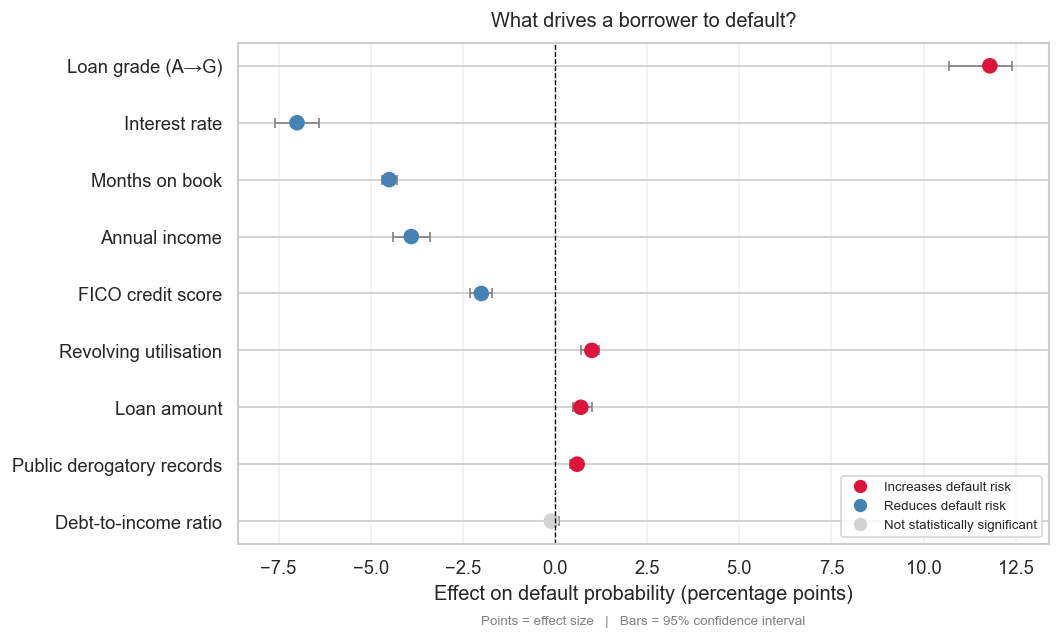

In [16]:
me = pd.DataFrame([
    ("Loan grade (A→G)",          11.8, 10.7, 12.4),
    ("Interest rate",             -7.0, -7.6, -6.4),
    ("Months on book",           -4.5, -4.7, -4.3),
    ("Annual income",            -3.9, -4.4, -3.4),
    ("FICO credit score",        -2.0, -2.3, -1.7),
    ("Revolving utilisation",     1.0,  0.7,  1.2),
    ("Loan amount",               0.7,  0.5,  1.0),
    ("Public derogatory records", 0.6,  0.4,  0.7),
    ("Debt-to-income ratio",     -0.1, -0.2,  0.1),
], columns=["label", "effect", "lo", "hi"])

me = me.reindex(me["effect"].abs().sort_values().index)

# Significant = CI does not cross zero
me["sig"] = ~((me["lo"] < 0) & (me["hi"] > 0))

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = []
for _, r in me.iterrows():
    if not r["sig"]:
        colors.append("lightgray")
    elif r["effect"] > 0:
        colors.append("crimson")
    else:
        colors.append("steelblue")

ax.errorbar(me["effect"], me["label"],
            xerr=[me["effect"] - me["lo"], me["hi"] - me["effect"]],
            fmt="none", ecolor="gray", elinewidth=1, capsize=3, zorder=1)
ax.scatter(me["effect"], me["label"], color=colors, s=70, zorder=2)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Effect on default probability (percentage points)")
ax.set_title("What drives a borrower to default?", fontsize=12, pad=10)

# Legend
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="crimson",
           markersize=9, label="Increases default risk"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=9, label="Reduces default risk"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="lightgray",
           markersize=9, label="Not statistically significant"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=8, frameon=True)

ax.text(0.5, -0.16,
        "Points = effect size   |   Bars = 95% confidence interval",
        transform=ax.transAxes, ha="center", fontsize=8, color="gray")

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../output/figures/marginal_effects.png", dpi=150)
plt.show()


In [17]:
print("=== LOGISTIC (PD) ===")
print("intercept:", lr.intercept_[0])
for f, c in zip(features, lr.coef_[0]):
    print(f"{f}: {c}")

print("\n=== SCALER ===")
for f, m, s in zip(features, scaler.mean_, scaler.scale_):
    print(f"{f}: mean={m}, scale={s}")

# PD percentiles for benchmark
all_proba = lr.predict_proba(scaler.transform(X))[:, 1]
pcts = np.percentile(all_proba, np.arange(0, 101, 5))
print("\n=== PD PERCENTILES ===")
print("[" + ", ".join(f"{p:.4f}" for p in pcts) + "]")

=== LOGISTIC (PD) ===
intercept: -1.8413829377535325
int_rate: 0.05140241935700668
dti: 0.03812587438305077
fico: -0.20870180445778166
loan_amnt: 0.07963701758347476
annual_inc: -0.3685354209067973
revol_util: -0.05066565800928426
delinq_2yrs: -0.007801818367478535
open_acc: 0.05712598158019652
pub_rec: 0.014655815641732465
term: 0.052811628167129615
grade_num: 0.45467498890930497

=== SCALER ===
int_rate: mean=0.13193573225586414, scale=0.047335947827887206
dti: mean=18.590182253851268, scale=11.835460761550017
fico: mean=698.3855026453826, scale=31.756835669395752
loan_amnt: mean=14773.478883717133, scale=8885.08539006675
annual_inc: mean=77419.68188202348, scale=118542.96725893882
revol_util: mean=0.5214869101329693, scale=0.24351299271821275
delinq_2yrs: mean=0.328466313117367, scale=0.897194976500328
open_acc: mean=11.651925365678578, scale=5.549573671285468
pub_rec: mean=0.21532751317021226, scale=0.6115425238326924
term: mean=42.80207230618057, scale=10.815800834419292
grade_num

In [18]:
# Updated headline numbers
print(f"Delinquency rate: {df['delq90'].mean():.2%}")
print(f"Defaulted loans: {df['delq90'].sum():,}")

# Updated buffer numbers (from 04_buffer)
p_delq = df['delq90'].mean()
monthly_cf = df['installment'].sum()
base_buffer = monthly_cf * p_delq * 3
print(f"\nMonthly CF: ${monthly_cf:,.0f}")
print(f"Base buffer: ${base_buffer:,.0f}")
print(f"Buffer % of monthly CF: {base_buffer/monthly_cf:.2%}")

# Stress scenarios
for label, rate in [("Mild (+25%)", p_delq*1.25), 
                     ("Moderate (+50%)", p_delq*1.50),
                     ("Severe (2007 peak)", 0.35)]:
    buf = monthly_cf * rate * 3
    print(f"{label}: ${buf:,.0f} ({buf/monthly_cf:.1%})")

Delinquency rate: 12.87%
Defaulted loans: 290,732

Monthly CF: $1,006,874,746
Base buffer: $388,760,001
Buffer % of monthly CF: 38.61%
Mild (+25%): $485,950,001 (48.3%)
Moderate (+50%): $583,140,002 (57.9%)
Severe (2007 peak): $1,057,218,483 (105.0%)
